<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-6/notebooks/04_timeseries_bilstm_tensorflow_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 4: Fermentation Risk Monitoring with a Keras BiLSTM
Use a bidirectional recurrent model for multivariate sensor sequences: temperature, pH, CO2, and Brix.

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## Learning route

Fermentation measurements form an ordered sequence. A BiLSTM summarizes patterns using both earlier and later time steps within each complete sequence.

![Neural-network patterns for different food data](https://github.com/khairuladib94/dl-food-research/blob/main/session-6/assets/session6-network-patterns.png?raw=1)

This is appropriate for retrospective classification of a completed run. A real-time alarm should use only information available up to the alert time.


## 1. Prepare the notebook environment

We begin with the libraries used throughout the case study. Setting TensorFlow's log level before importing TensorFlow keeps the workshop output focused on the results.


In [16]:
from pathlib import Path
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


### Make the data portable

The next cell first looks for `fermentation_timeseries.npz` beside the notebook. If the file is absent—as it will be in a fresh Colab session—it downloads the public workshop copy. This keeps the notebook runnable without mounting Google Drive.


In [31]:
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'fermentation_timeseries.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-6/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')


Dataset ready: /content/dl-food-research-data/fermentation_timeseries.npz


### Make the experiment repeatable

Fixed random seeds make the teaching run easier to reproduce. The helper functions also keep splitting, standardisation, and training-history summaries consistent across the five examples.

> **Important:** standardisation statistics are calculated from the training set only. Using the test set here would leak information into the model.


In [32]:
SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

def make_split(n, test_fraction=0.2):
    idx = np.arange(n)
    np.random.shuffle(idx)
    cut = int(n * (1 - test_fraction))
    return idx[:cut], idx[cut:]

def standardize(train, test, axis=0):
    mean = train.mean(axis=axis, keepdims=True)
    std = train.std(axis=axis, keepdims=True) + 1e-8
    return (train - mean) / std, (test - mean) / std, mean, std

def history_table(history):
    hist = pd.DataFrame(history.history)
    return hist.tail(5).round(4)


NumPy: 2.0.2
Pandas: 2.2.2
TensorFlow: 2.20.0
Keras: 3.13.2


### Set up reusable plots

These helpers turn Keras histories and classification results into readable diagnostics. They do not affect training; they only help us inspect what the model learned.


In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (8, 4.8),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10
})

def plot_history(history, metrics=None, title='Training history'):
    hist = pd.DataFrame(history.history)
    metrics = metrics or [c for c in hist.columns if not c.startswith('val_')]
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        ax.plot(hist.index + 1, hist[metric], label=f'train {metric}', linewidth=2)
        val_metric = f'val_{metric}'
        if val_metric in hist:
            ax.plot(hist.index + 1, hist[val_metric], label=f'validation {metric}', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()
    fig.suptitle(title, y=1.03, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_binary_confusion(y_true, y_pred, labels, title='Confusion matrix'):
    cm = confusion_matrix(y_true.astype(int), y_pred.astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


## 2. Load sequences and labels

The tensor shape is `(runs, time steps, sensor channels)`. Each label describes the whole fermentation run.


In [20]:
data = np.load(DATA_DIR / 'fermentation_timeseries.npz')
sequences = data['sequences'].astype('float32')
labels = data['labels'].astype('float32')


### Split and scale sensor channels

Each sensor is standardized using all time points from training runs only.


In [21]:
train_idx, test_idx = make_split(len(sequences))
X_train_raw, X_test_raw = sequences[train_idx], sequences[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

print('Sequence tensor:', X_train.shape)
pd.Series(y_train).value_counts().rename(index={0: 'normal', 1: 'risk'})


Sequence tensor: (448, 90, 4)


,count
normal,225
risk,223


### Inspect temporal profiles

Plotting normal and risky runs helps connect model inputs to process behaviour and sensor dynamics.


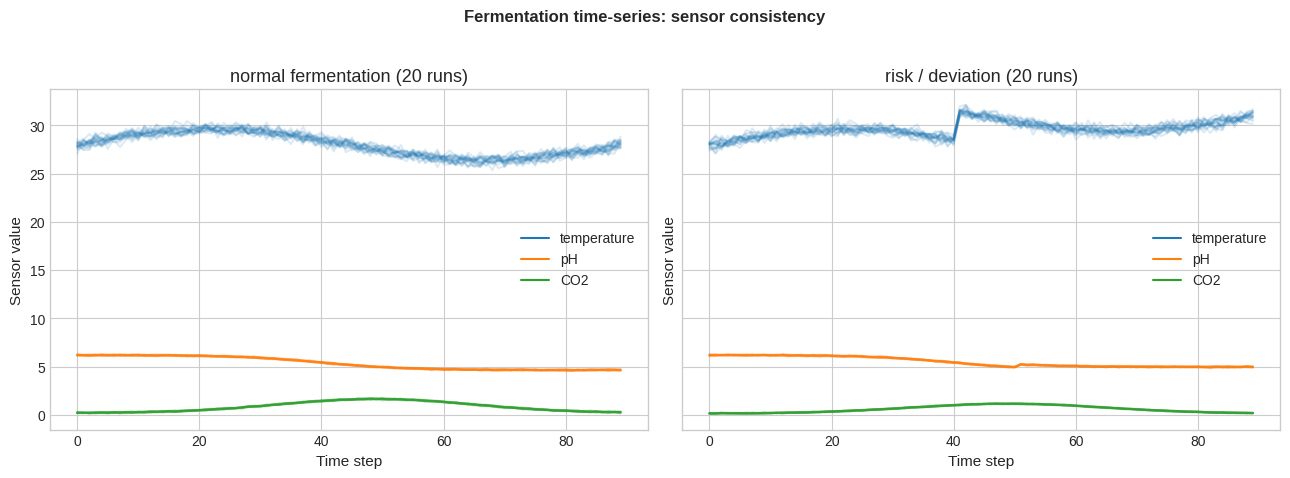

In [34]:
channel_names = ['temperature', 'pH', 'CO2']
# Define fixed colors for each channel
channel_colors = ['tab:blue', 'tab:orange', 'tab:green']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)

num_samples = 20

for cls, ax, title in [(0, axes[0], 'normal fermentation'), (1, axes[1], 'risk / deviation')]:
    # Select multiple indices for the current class
    all_indices = np.where(labels == cls)[0]
    subset_indices = all_indices[:num_samples]

    for idx in subset_indices:
        for ch, (name, color) in enumerate(zip(channel_names, channel_colors)):
            # Only add label for the first sequence to avoid duplicate legends
            label = name if idx == subset_indices[0] else None
            ax.plot(sequences[idx, :, ch], label=label, color=color, linewidth=1.5, alpha=0.15)

    ax.set_title(f"{title} ({len(subset_indices)} runs)")
    ax.set_xlabel('Time step')
    ax.set_ylabel('Sensor value')

    # Increase legend opacity for readability
    leg = ax.legend()
    for lh in leg.legend_handles:
        lh.set_alpha(1.0)

fig.suptitle('Fermentation time-series: sensor consistency', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Build the BiLSTM

The bidirectional layer reads a complete sequence in both directions, then dense layers classify the summary.


In [23]:
model = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Bidirectional(layers.LSTM(32, return_sequences=False)),
    layers.Dropout(0.20),
    layers.Dense(24, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


### Configure binary classification

Binary cross-entropy trains the sigmoid probability of fermentation risk.


In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 64)             │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,057 (43.19 KB)

 Trainable params: 11,057 (43.19 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train and monitor

Learning curves show whether the model improves consistently or begins to memorize the training runs.


In [25]:
history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=12,
    batch_size=32,
    verbose=0
)
history_table(history)


,accuracy,loss,val_accuracy,val_loss
7,1.0,0.0050,1.0,0.0025
8,1.0,0.0031,1.0,0.0017
9,1.0,0.0025,1.0,0.0012
10,1.0,0.0016,1.0,0.0008
11,1.0,0.0011,1.0,0.0006


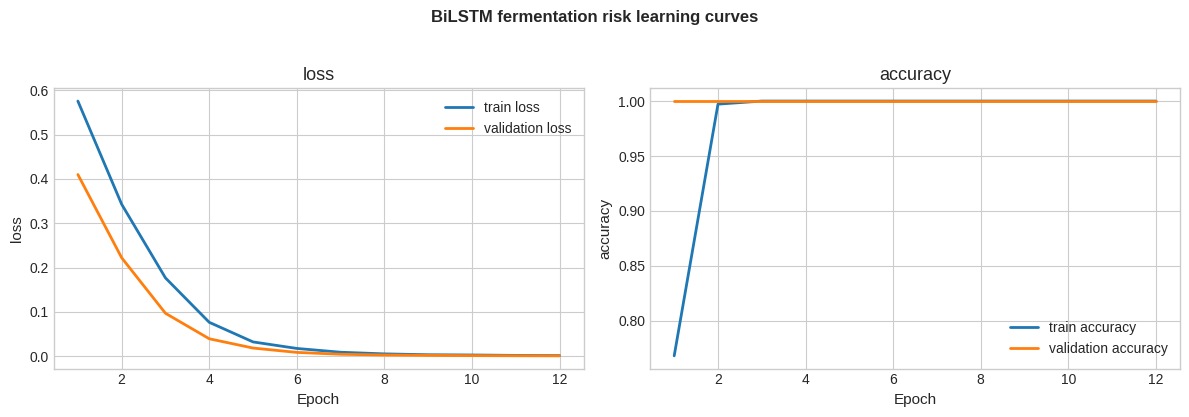

In [26]:
plot_history(history, metrics=['loss', 'accuracy'], title='BiLSTM fermentation risk learning curves')


## 5. Evaluate probabilities

Probability outputs allow risk thresholds to be chosen for the process consequences, not only for accuracy.


In [27]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
prob = model.predict(X_test[:12], verbose=0).ravel()
print(f'Test accuracy: {acc:.3f}')


Test accuracy: 1.000


### Inspect sample decisions

The table exposes the exact `0.5` threshold used in this teaching example.


In [28]:
pd.DataFrame({
    'true_risk': y_test[:12].astype(int),
    'prob_risk': prob,
    'predicted_risk': (prob >= 0.5).astype(int)
}).round(3)


,true_risk,prob_risk,predicted_risk
0,0,0.000,0
1,1,0.999,1
2,0,0.000,0
3,1,0.999,1
4,0,0.000,0
5,1,0.999,1
6,1,0.999,1
7,1,0.999,1
8,1,0.999,1
9,0,0.000,0


### Count error types

The confusion matrix distinguishes missed risky runs from false alarms.


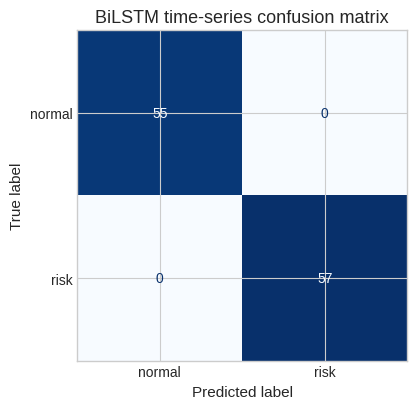

array([[55,  0],
       [ 0, 57]])

In [29]:
prob_full = model.predict(X_test, verbose=0).ravel()
pred_full = (prob_full >= 0.5).astype(int)
plot_binary_confusion(y_test, pred_full, labels=['normal', 'risk'], title='BiLSTM time-series confusion matrix')


### Revisit the sensor traces

Probability distributions and held-out CO2 traces help explain why some sequences are easier to classify.


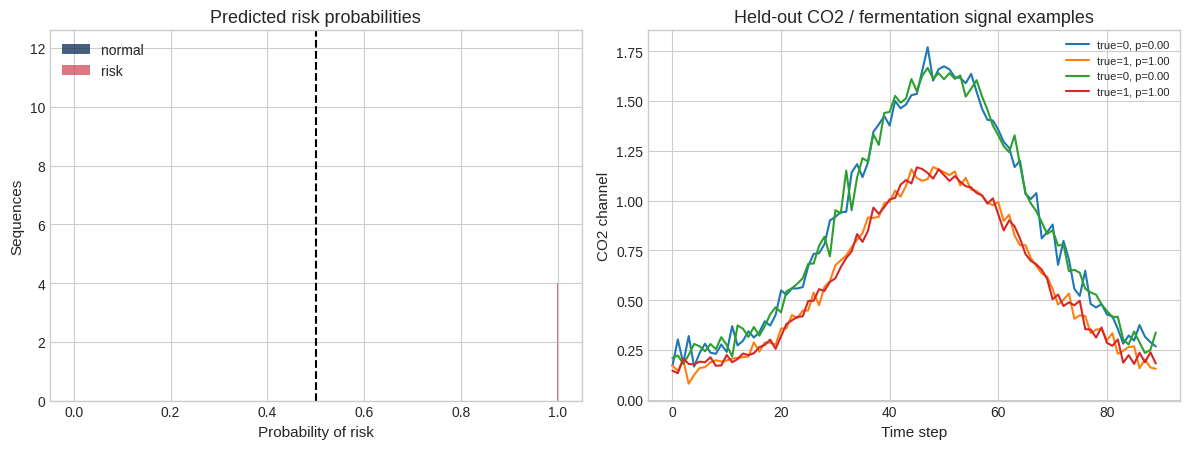

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(prob_full[y_test == 0], bins=14, alpha=0.75, label='normal', color='#0B2A55')
axes[0].hist(prob_full[y_test == 1], bins=14, alpha=0.75, label='risk', color='#D1495B')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Predicted risk probabilities')
axes[0].set_xlabel('Probability of risk')
axes[0].set_ylabel('Sequences')
axes[0].legend()

for idx in range(min(4, len(X_test_raw))):
    axes[1].plot(X_test_raw[idx, :, 2], label=f'true={int(y_test[idx])}, p={prob_full[idx]:.2f}')
axes[1].set_title('Held-out CO2 / fermentation signal examples')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('CO2 channel')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## How to read the evidence

![Three complementary views of model quality](https://github.com/khairuladib94/dl-food-research/blob/main/session-6/assets/session6-evaluation-views.png?raw=1)

Learning curves describe optimization, predictions show sample-level behaviour, and error summaries expose the kinds of mistakes being made. A publishable conclusion needs all three, plus external validation that matches the intended use.


## Teaching notes
- For deployment, evaluate on future batches rather than shuffled time windows.
- Add alert thresholds based on process risk, not only model accuracy.
- Sequence models need enough repeated process runs to generalise.